# Fase D: Visualizaciones de la incidencia notificada de dengue

Este notebook transforma las consultas analíticas de la Fase C en ocho visualizaciones reproducibles. Los conteos representan registros notificados del Parquet y no tasas de incidencia poblacional, porque el dataset no contiene denominadores de población.

In [11]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

rutas_candidatas = (
    Path.cwd() / "datos" / "procesados" / "dengue_consolidado.parquet",
    Path.cwd().parent / "datos" / "procesados" / "dengue_consolidado.parquet",
)
ruta_parquet = next((ruta.resolve() for ruta in rutas_candidatas if ruta.exists()), None)
if ruta_parquet is None:
    raise FileNotFoundError("No se encontro datos/procesados/dengue_consolidado.parquet")

con = duckdb.connect()
ruta_sql = ruta_parquet.as_posix()
con.execute(f"""
    CREATE OR REPLACE VIEW fact_dengue AS
    SELECT
        TRY_CAST(ANO AS INTEGER) AS ano,
        TRY_CAST(SEMANA AS INTEGER) AS semana,
        CAST(Departamento_ocurrencia AS VARCHAR) AS departamento,
        CAST(Municipio_ocurrencia AS VARCHAR) AS municipio,
        CAST(AREA AS VARCHAR) AS area,
        CAST(SEXO AS VARCHAR) AS sexo,
        TRY_CAST(EDAD AS DOUBLE) AS edad,
        CAST(PAC_HOS AS VARCHAR) AS pac_hos
    FROM read_parquet('{ruta_sql}')
""")

print(f"Parquet utilizado: {ruta_parquet}")
print(f"Registros disponibles: {con.sql('SELECT COUNT(*) AS registros FROM fact_dengue').fetchone()[0]:,}")

Parquet utilizado: C:\Users\santi\OneDrive\Escritorio\grupo-4-p1\datos\procesados\dengue_consolidado.parquet
Registros disponibles: 581,071


In [12]:
# Resultados base de las consultas de la Fase C y agregaciones complementarias.
resultado_1 = con.sql("""
    SELECT ano, semana, COUNT(*) AS casos_notificados
    FROM fact_dengue
    WHERE ano IS NOT NULL AND semana IS NOT NULL
    GROUP BY ano, semana
    ORDER BY ano, semana
""").df()

resultado_2 = con.sql("""
    SELECT departamento, municipio, COUNT(*) AS casos_notificados
    FROM fact_dengue
    GROUP BY departamento, municipio
    ORDER BY casos_notificados DESC
    LIMIT 10
""").df()

resultado_3 = con.sql("""
    WITH perfiles AS (
        SELECT
            CASE
                WHEN edad IS NULL THEN 'Sin dato'
                WHEN edad < 5 THEN '0-4'
                WHEN edad < 15 THEN '5-14'
                WHEN edad < 25 THEN '15-24'
                WHEN edad < 45 THEN '25-44'
                WHEN edad < 65 THEN '45-64'
                ELSE '65 o mas'
            END AS rango_edad,
            COALESCE(NULLIF(TRIM(sexo), ''), 'Sin dato') AS sexo
        FROM fact_dengue
    )
    SELECT rango_edad, sexo, COUNT(*) AS casos_notificados
    FROM perfiles
    GROUP BY rango_edad, sexo
""").df()

resultado_4 = con.sql("""
    SELECT departamento, COUNT(*) AS casos_notificados,
           SUM(CASE WHEN TRIM(pac_hos) = '1' THEN 1 ELSE 0 END) AS casos_hospitalizados,
           ROUND(100.0 * SUM(CASE WHEN TRIM(pac_hos) = '1' THEN 1 ELSE 0 END) / COUNT(*), 2)
               AS porcentaje_hospitalizacion
    FROM fact_dengue
    GROUP BY departamento
    HAVING COUNT(*) >= 10
    ORDER BY porcentaje_hospitalizacion DESC, casos_notificados DESC
""").df()

resultado_5 = con.sql("""
    SELECT CASE
               WHEN edad IS NULL THEN 'Sin dato'
               WHEN edad < 5 THEN '0-4'
               WHEN edad < 15 THEN '5-14'
               WHEN edad < 25 THEN '15-24'
               WHEN edad < 45 THEN '25-44'
               WHEN edad < 65 THEN '45-64'
               ELSE '65 o mas'
           END AS rango_edad,
           COUNT(*) AS casos_notificados
    FROM fact_dengue
    GROUP BY 1
""").df()

resultado_6 = con.sql("""
    WITH departamentos AS (
        SELECT departamento, COUNT(*) AS casos_notificados
        FROM fact_dengue
        GROUP BY departamento
        ORDER BY casos_notificados DESC
        LIMIT 5
    )
    SELECT f.ano, f.semana, f.departamento, COUNT(*) AS casos_notificados
    FROM fact_dengue AS f
    INNER JOIN departamentos AS d ON f.departamento = d.departamento
    GROUP BY f.ano, f.semana, f.departamento
    ORDER BY f.ano, f.semana, f.departamento
""").df()

resultado_7 = con.sql("""
    SELECT edad, CASE WHEN TRIM(pac_hos) = '1' THEN 'Hospitalizado' ELSE 'No hospitalizado' END AS estado_hospitalizacion
    FROM fact_dengue
    WHERE edad IS NOT NULL AND edad BETWEEN 0 AND 100
""").df()

resultado_8 = con.sql("""
    SELECT CASE TRIM(area)
               WHEN '1' THEN 'Area 1'
               WHEN '2' THEN 'Area 2'
               WHEN '3' THEN 'Area 3'
               ELSE 'Sin dato'
           END AS categoria_area,
           COUNT(*) AS casos_notificados
    FROM fact_dengue
    GROUP BY 1
    ORDER BY casos_notificados DESC
""").df()

for numero, resultado in enumerate((resultado_1, resultado_2, resultado_3, resultado_4,
                                    resultado_5, resultado_6, resultado_7, resultado_8), start=1):
    assert not resultado.empty, f"La consulta {numero} no devolvio filas"

print("Validacion OK: las 8 consultas tienen resultados.")

Validacion OK: las 8 consultas tienen resultados.


## Visualización 1. Evolución semanal de registros notificados

Esta serie temporal reutiliza la agregación año-semana de la Consulta 4 de la Fase C.

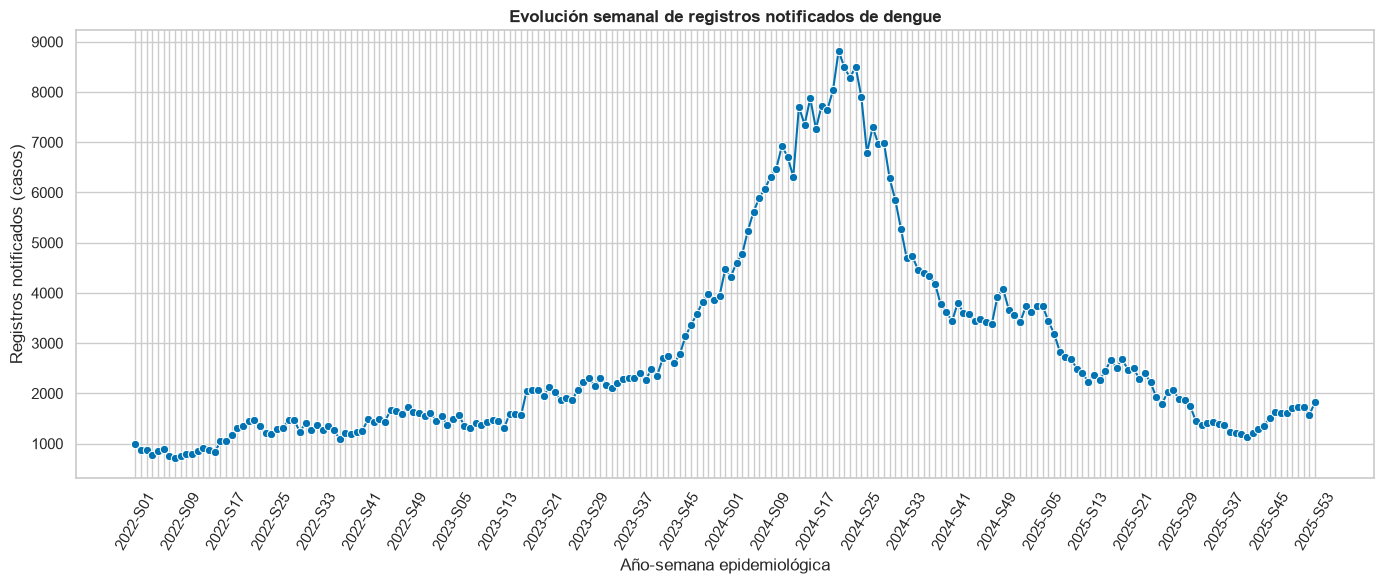

In [13]:
serie = resultado_1.copy()
serie["periodo"] = serie["ano"].astype(str) + "-S" + serie["semana"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=serie, x="periodo", y="casos_notificados", marker="o", linewidth=1.5, ax=ax)
ax.set_title("Evolución semanal de registros notificados de dengue")
ax.set_xlabel("Año-semana epidemiológica")
ax.set_ylabel("Registros notificados (casos)")
ax.tick_params(axis="x", rotation=60)
for indice, etiqueta in enumerate(ax.get_xticklabels()):
    etiqueta.set_visible(indice % 8 == 0)
plt.tight_layout()
plt.show()

**Insight:** La serie permite localizar semanas con picos y valles de notificación a lo largo de 2022-2025. Estos cambios describen el comportamiento de los registros reportados y deben interpretarse junto con posibles variaciones en vigilancia y oportunidad de reporte.

## Visualización 2. Municipios con más registros notificados

Esta comparación categórica parte de la Consulta 3 de la Fase C y muestra los diez municipios con mayor volumen.

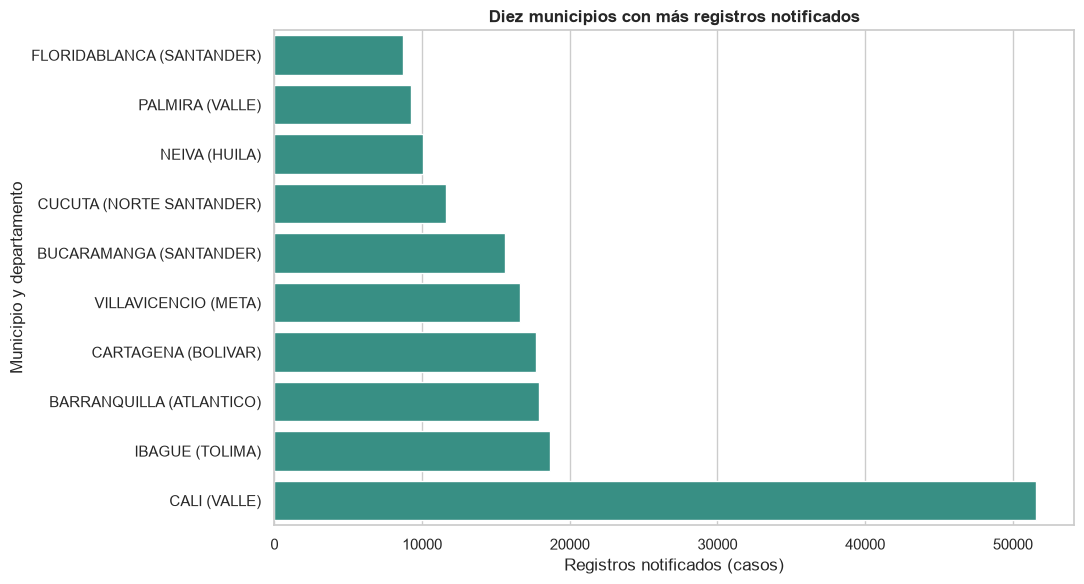

In [14]:
municipios = resultado_2.copy()
municipios["territorio"] = municipios["municipio"] + " (" + municipios["departamento"] + ")"
municipios = municipios.sort_values("casos_notificados")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=municipios, x="casos_notificados", y="territorio", color="#2a9d8f", ax=ax)
ax.set_title("Diez municipios con más registros notificados")
ax.set_xlabel("Registros notificados (casos)")
ax.set_ylabel("Municipio y departamento")
plt.tight_layout()
plt.show()

**Insight:** Los registros se concentran en pocos municipios, lo que ayuda a priorizar la revisión territorial y la comunicación de resultados. Esta comparación es de volumen absoluto; no equivale a mayor riesgo porque no incorpora la población de cada municipio.

## Visualización 3. Perfil de edad y sexo

Este mapa de calor utiliza la Consulta 5 de la Fase C para comparar simultáneamente dos variables categóricas.

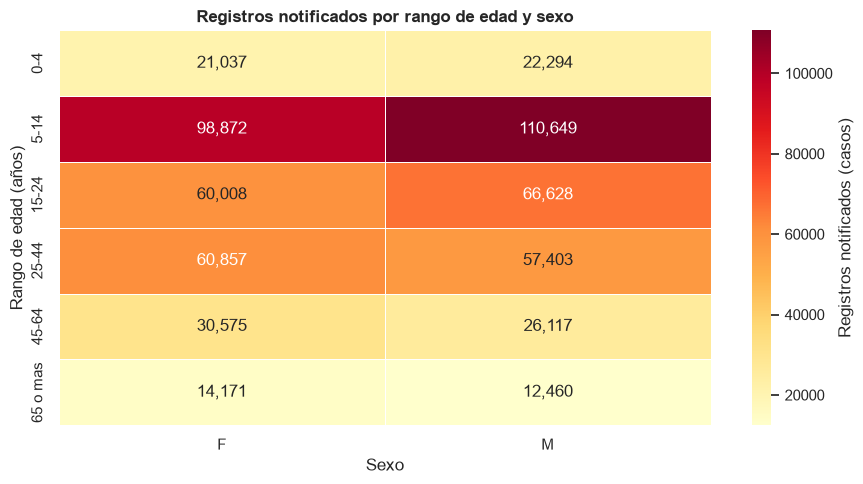

In [15]:
perfil = resultado_3.pivot(index="rango_edad", columns="sexo", values="casos_notificados").fillna(0)
orden_edades = ["0-4", "5-14", "15-24", "25-44", "45-64", "65 o mas", "Sin dato"]
perfil = perfil.reindex([edad for edad in orden_edades if edad in perfil.index])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(perfil, annot=True, fmt=",.0f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Registros notificados (casos)"}, ax=ax)
ax.set_title("Registros notificados por rango de edad y sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Rango de edad (años)")
plt.tight_layout()
plt.show()

**Insight:** La mayor intensidad de color identifica los rangos de edad y sexo con más registros dentro del conjunto observado. La figura sirve para comparar composición demográfica, pero no permite concluir diferencias de riesgo sin denominadores poblacionales por grupo.

## Visualización 4. Porcentaje de hospitalización por departamento

Esta visualización retoma la Consulta 6 de la Fase C y ordena los departamentos por porcentaje de registros con `PAC_HOS = 1`.

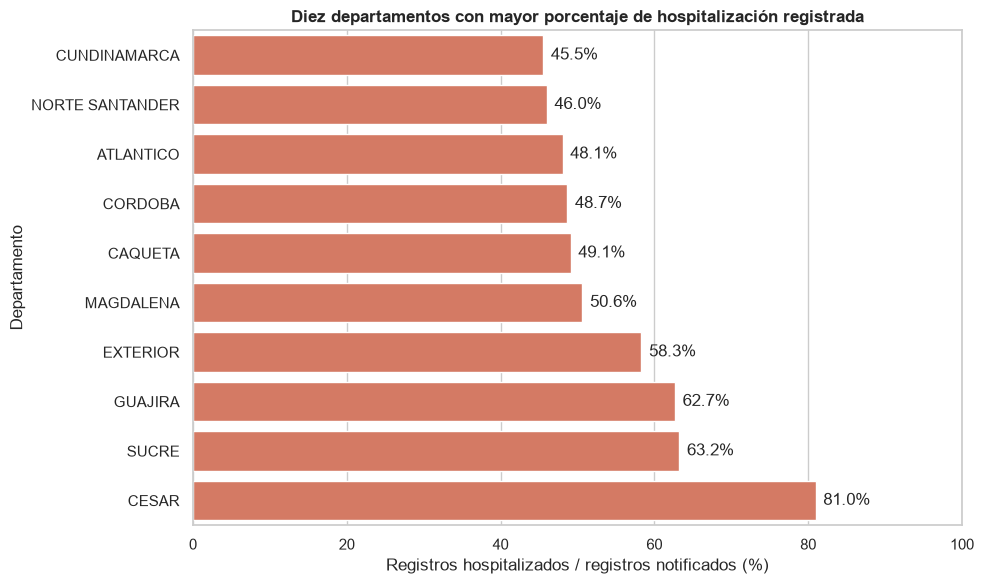

In [16]:
hospitalizacion = resultado_4.sort_values("porcentaje_hospitalizacion", ascending=False).head(10).sort_values("porcentaje_hospitalizacion")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=hospitalizacion, x="porcentaje_hospitalizacion", y="departamento", color="#e76f51", ax=ax)
ax.set_title("Diez departamentos con mayor porcentaje de hospitalización registrada")
ax.set_xlabel("Registros hospitalizados / registros notificados (%)")
ax.set_ylabel("Departamento")
ax.set_xlim(0, 100)
for barra, porcentaje in zip(ax.patches, hospitalizacion["porcentaje_hospitalizacion"]):
    ax.text(porcentaje + 1, barra.get_y() + barra.get_height() / 2, f"{porcentaje:.1f}%", va="center")
plt.tight_layout()
plt.show()

**Insight:** El porcentaje muestra la proporción de registros notificados que tiene hospitalización registrada en cada departamento, no una tasa poblacional de hospitalización. Los departamentos del extremo superior pueden priorizar una revisión de los perfiles clínicos y de la calidad del registro `PAC_HOS`.

## Visualización 5. Distribución univariada de la edad

El histograma resume la distribución de edad de los registros con edades entre 0 y 100 años.

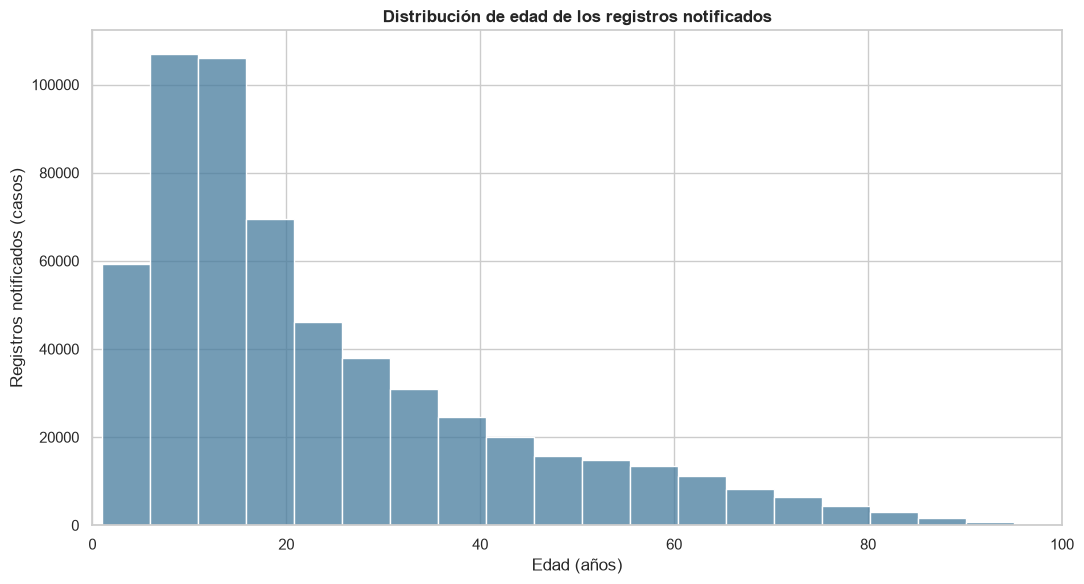

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(data=resultado_7, x="edad", bins=20, color="#457b9d", edgecolor="white", ax=ax)
ax.set_title("Distribución de edad de los registros notificados")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Registros notificados (casos)")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

**Insight:** La distribución permite reconocer en qué edades se concentra la carga de notificaciones y si existen colas hacia edades mayores. Es una distribución de registros observados, por lo que no debe confundirse con la distribución del riesgo de dengue en la población.

## Visualización 6. Evolución semanal en los cinco departamentos con más registros

La consulta complementaria permite comparar la dimensión temporal y territorial sin saturar la figura con los 33 departamentos.

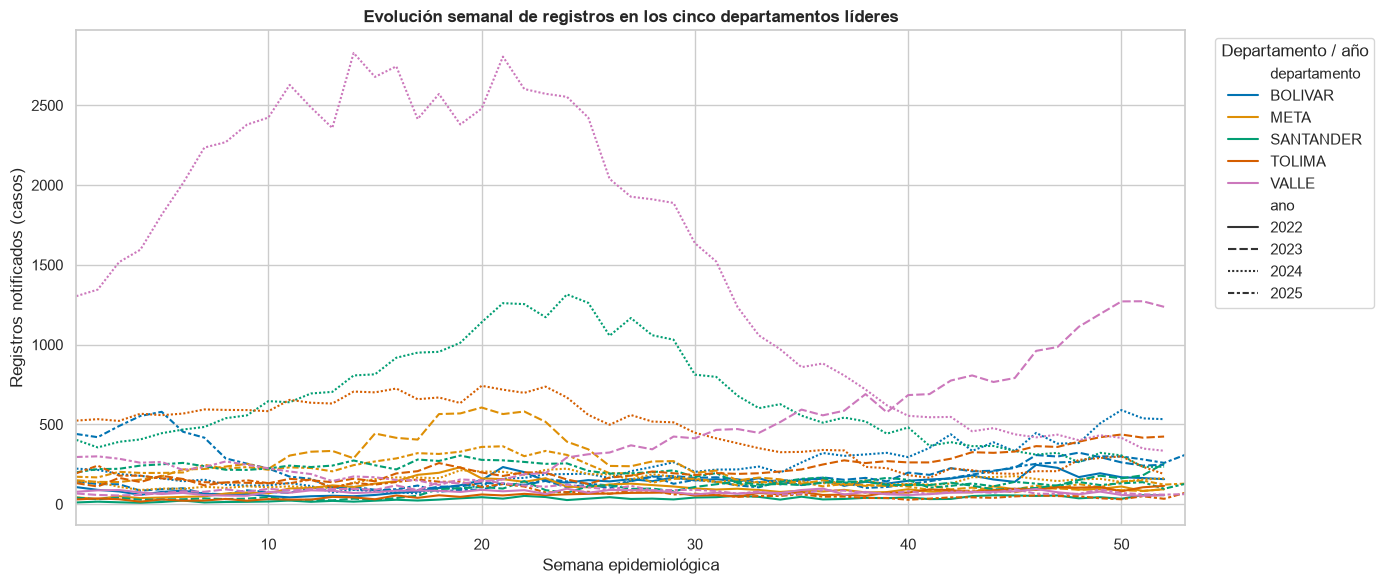

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=resultado_6, x="semana", y="casos_notificados", hue="departamento", style="ano", markers=False, ax=ax)
ax.set_title("Evolución semanal de registros en los cinco departamentos líderes")
ax.set_xlabel("Semana epidemiológica")
ax.set_ylabel("Registros notificados (casos)")
ax.set_xlim(1, 53)
ax.legend(title="Departamento / año", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Insight:** La figura muestra si los departamentos líderes comparten los mismos picos semanales o si sus patrones son distintos. Comparar varios años ayuda a separar un comportamiento recurrente de un aumento puntual en los registros notificados.

## Visualización 7. Relación entre edad y hospitalización registrada

El diagrama de caja evalúa la relación bivariada entre edad y el estado de hospitalización, manteniendo solo edades entre 0 y 100 años.

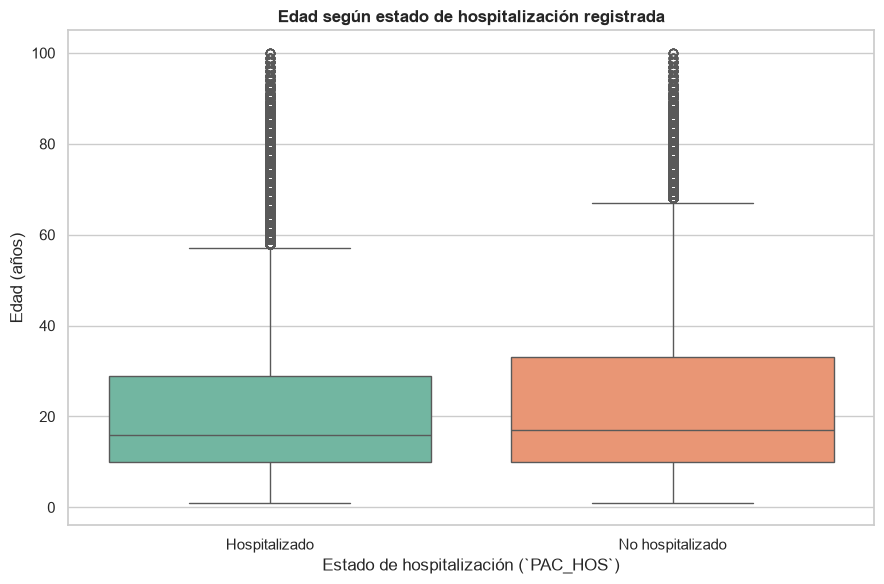

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=resultado_7, x="estado_hospitalizacion", y="edad", hue="estado_hospitalizacion", legend=False, palette="Set2", ax=ax)
ax.set_title("Edad según estado de hospitalización registrada")
ax.set_xlabel("Estado de hospitalización (`PAC_HOS`)")
ax.set_ylabel("Edad (años)")
plt.tight_layout()
plt.show()

**Insight:** Las medianas y la dispersión permiten comparar la edad de los registros hospitalizados frente a los no hospitalizados. Una diferencia descriptiva entre cajas no prueba causalidad ni gravedad, porque el análisis no controla por sexo, territorio, año u otras variables clínicas.

## Visualización 8. Registros por categoría de área

Esta comparación categórica resume la distribución de registros según el código de área disponible en el Parquet.

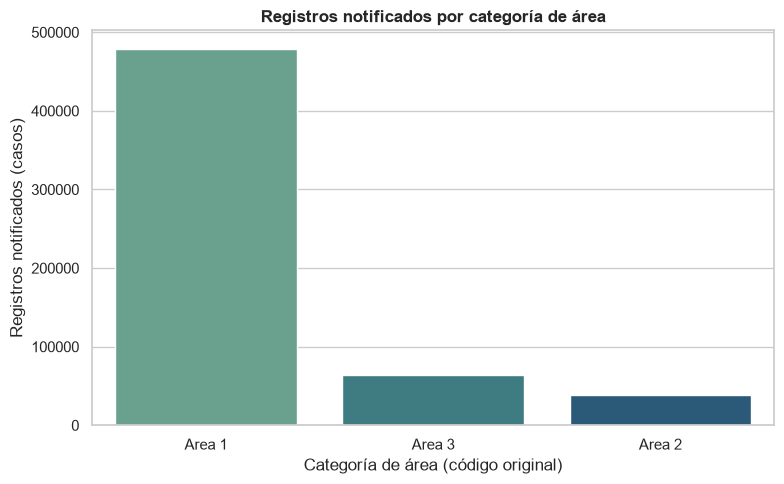

In [20]:
area = resultado_8.sort_values("casos_notificados", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=area, x="categoria_area", y="casos_notificados", hue="categoria_area", legend=False, palette="crest", ax=ax)
ax.set_title("Registros notificados por categoría de área")
ax.set_xlabel("Categoría de área (código original)")
ax.set_ylabel("Registros notificados (casos)")
plt.tight_layout()
plt.show()

**Insight:** La categoría de área con la barra más alta concentra la mayor cantidad absoluta de notificaciones del conjunto observado. Como el Parquet conserva códigos y no documenta aquí una etiqueta geográfica más específica, el gráfico mantiene los códigos originales y evita asignarles una interpretación no verificada.

## Validación y cierre

Las ocho visualizaciones cubren una serie de tiempo, comparaciones categóricas, relaciones bivariadas y una distribución univariada. Todas usan conteos o porcentajes calculados desde las consultas de la Fase C y están acompañadas por un insight interpretativo.